# AI Application Patterns

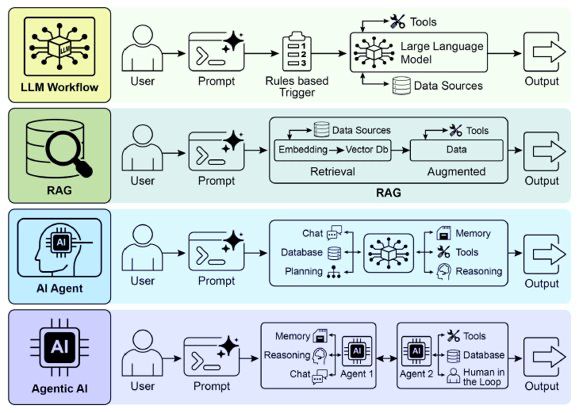

# Env Vars

In [1]:
# Load environment variables from .env file

from dotenv import load_dotenv

load_dotenv()

True

# Create Test Questions

In [2]:
import pandas as pd

questions = [
    "What's the emergency contact number for the electric utility?",
    "What was the record of the New England Patriots for the 2024 season?",
    "How many stars on the United States flag?"
]

# Initialize Agentic Evaluator

In [3]:
from ibm_watsonx_gov.entities.state import EvaluationState
from typing import Optional, TypedDict

class AppState(TypedDict):
    input_text: str #The user's raw input query or question
    ground_truth: str #Reference/correct answer (if available). Used for evaluation
    context: list[str] #Context fetched from sources
    generated_text: str #The final output generated by the LLM after processing all contexts
    # question:str
    # context: Optional[list[str]] = []
    # generated_text: Optional[str] = None
    # ground_truth: Optional[str] = None
    # record_id: Optional[str] = None
    # record_timestamp: Optional[str] = None
    # message_id: Optional[str] = None
    # context: Optional[str] = None
    pass





In [4]:
from ibm_watsonx_gov.evaluators.agentic_evaluator import AgenticEvaluator
from ibm_watsonx_gov.metrics import FaithfulnessMetric, ContextRelevanceMetric, AnswerRelevanceMetric


evaluator = AgenticEvaluator()

/Users/ananddas/github/vista/demo-env/lib/python3.11/site-packages/ibm_watsonx_gov/tools/utils/environment.py:55: UserWarning: Since WATSONX_REGION is not provided in the environment variable, the Dallas region will be used as the default.
  warnings.warn(


Custom exporter logging initialized. App name: Anands_ipykernel_launcher
Traceloop exporting traces to a custom exporter

Metrics are disabled


In [5]:
from ibm_watsonx_gov.entities.foundation_model import WxAIFoundationModel
from ibm_watsonx_gov.entities.llm_judge import LLMJudge
import os

PROJECT_ID = os.getenv("WATSONX_PROJECT_ID")

llm_judge = LLMJudge(
    model=WxAIFoundationModel(
        model_id="meta-llama/llama-3-3-70b-instruct",
        project_id=PROJECT_ID,
    )
)

# Demo 1 - RAG Agent Two Ways

In [6]:
# Load documents from the data directory

from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)
docs = directory_loader.load()

In [7]:
# Chunk the documents

from langchain_text_splitters import RecursiveCharacterTextSplitter
import tiktoken

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o").encode(text)
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=750,
    chunk_overlap=0,
    length_function=tiktoken_len,
)

chunks = text_splitter.split_documents(docs)
len(chunks)

206

In [8]:
# Get the embedding model

from langchain_openai.embeddings import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [9]:
# Create a Qdrant vector store in memory

from langchain_community.vectorstores import Qdrant
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

colllection_name = "utility-docs"

# Initialize the Qdrant client
qdrant_client = QdrantClient(location=":memory:")

# Create a collection in Qdrant
qdrant_client.create_collection(
    collection_name=colllection_name, 
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE)
)

# Initialize QdrantVectorStore with the Qdrant client
qdrant_vector_store = QdrantVectorStore(
    client=qdrant_client, 
    collection_name=colllection_name, 
    embedding=embeddings
)

# Add the docs to the vector store
qdrant_vector_store.add_documents(chunks)

['764fd655efe948f980809937440ccb21',
 '282081c33f7c4438be035ca121a4f30f',
 'af80ec45b3dc4dae92e3435eac2435c0',
 'f720a1d818434c708064428ea2fa8e0d',
 '13e6fd323d4e4b1793e91f7d88051316',
 '01c6b6b827014f83ad2d72251841059f',
 '9ba095c81f014a6983df61c3ec057e0f',
 '9d6019be7e4d4326ab8a22ec1daad8a0',
 'e6458bdefedb486e94664960732eb915',
 '44ed31207bc3434c999adbf8a052431f',
 '1f4bab6d24274af6924fc6a4e41902af',
 '388248ad508f4cdeb14a0397eb9956d4',
 '71d321adfdd1436ab136103b0180544d',
 '126c4f1aa3844067ac91d26465ea3c79',
 '4f7f8a1e437146a1995763eed60a1bda',
 '7d6ba0981ff44fa18ce72d4bf3434af0',
 '0bdb4f13b9d34193b4bc1f6b815cb51d',
 'ca6e9880d73347cc955745ca76af7070',
 'f5b5387724e54dc59a49fb001b144ed6',
 '61ca6819981e40a9948d972ad0040ba4',
 'e56b8bd111734d33b1698073ed9d2f1b',
 '339a7c4bc6924889a53ec2016ca74a36',
 '20872e27a5b9441691aed9ccd438aca3',
 'cab4ca1d96d74acb9dda496bf02a91c4',
 '18d4705727614e37bf4f703bdb462bc4',
 '0a7e4f872d8e4566809b7072be581b55',
 '240f28755798401894e45aaf04cdf35f',
 

In [10]:
# Create a retriever - "R" in RAG

retriever = qdrant_vector_store.as_retriever()

In [11]:
# Create a simple prompt

from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
CONTEXT:
{context}

QUERY:
{query}

Use the provided context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context respond with "I don't know"
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

In [12]:
# Create the chat model

from langchain_openai import ChatOpenAI

chat_model = ChatOpenAI(model="gpt-4o-mini")

In [13]:
# Define state that will be passed between agent nodes

# from typing_extensions import TypedDict
# from langchain_core.documents import Document

# class RagState(TypedDict):
#   question: str
#   context: list[Document]
#   response: str

In [14]:
# Build and compile the graph

from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import START, StateGraph

@evaluator.evaluate_context_relevance(compute_real_time=True, metrics=[ContextRelevanceMetric(llm_judge=llm_judge)])
def retrieve(state: AppState) -> dict:
    retrieved_docs = retriever.invoke(state["input_text"])
    # Convert Document objects to strings (extract page_content)
    context_strings = [doc.page_content for doc in retrieved_docs]
    return {"context": context_strings}

@evaluator.evaluate_faithfulness(compute_real_time=True)
def generate(state: AppState) -> dict:
    generator_chain = chat_prompt | chat_model | StrOutputParser()
    response = generator_chain.invoke({"query": state["input_text"], "context":state["context"]})
    return {"generated_text": response}

builder = StateGraph(AppState)
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate")

rag_agent = builder.compile()

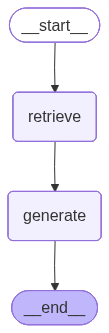

In [15]:
from IPython.display import Image, display

display(Image(rag_agent.get_graph(xray=True).draw_mermaid_png()))

## Test the Agentic Evaluator on a multiple inputs

In [16]:
evaluator.start_run()
for question in questions:
    result = rag_agent.invoke({"input_text": question, "interaction_id": "1"})
    print(f"Q: {question}")
    print(f"A: {result['generated_text']}\n")
evaluator.end_run()

eval_result = evaluator.get_result()
metric_result = eval_result.to_df()
metric_result

[Warning] No region provided : Using default region as us-south
Q: What's the emergency contact number for the electric utility?
A: The emergency contact number for the electric utility is (508) 261-7300.

Q: What was the record of the New England Patriots for the 2024 season?
A: I don't know.

Q: How many stars on the United States flag?
A: I don't know.



,message_id,generate.faithfulness,generate.latency,message.cost,message.duration,message.input_token_count,message.output_token_count,retrieve.context_relevance,retrieve.latency
0,0ff18e0242af9fc385776e9add84f39e,0.6667,1.251976,0.0,30.452900,0.0,0.0,0.8,28.971663
1,2648ee38e07405eb215663abc1f254b8,0.0000,0.909329,0.0,2.879155,0.0,0.0,0.0,1.940270
2,b341facdff0ac0f1a425799aa905d750,0.0000,0.719494,0.0,2.148463,0.0,0.0,0.0,1.402059


In [17]:
evaluator.get_nodes()

[Node(name='generate', func_name='generate', metrics_configurations=[], foundation_models=[FoundationModelInfo(model_name='gpt-4o-mini', model_id=None, provider='openai', type='chat')]),
 Node(name='retrieve', func_name='retrieve', metrics_configurations=[], foundation_models=[FoundationModelInfo(model_name='text-embedding-3-small', model_id=None, provider='openai', type='embedding')])]